In [95]:
import boto3
import base64 
import cv2
import io
import json
import numpy as np

import matplotlib.pyplot as plt

In [2]:
receipt_image = cv2.imread("../samples/mercadona_00016.jpg")
image_height, image_width, _ = receipt_image.shape
model_height, model_width = 640, 320
x_ratio = image_width/model_width
y_ratio = image_height/model_height

resized_image = cv2.resize(receipt_image, (model_width, model_height))
_, encoded_image = cv2.imencode(".jpg", resized_image)

In [15]:
encoded_image

array([255, 216, 255, ...,   0, 255, 217], dtype=uint8)

In [124]:
def resize_and_encode(image_path: str, model_height: int  = 640, model_width: int = 320) -> tuple:
    """
    Reads an image from the specified file path, resizes it to the specified dimensions,
    and encodes it into JPEG format. Also returns the ratios of the original image 
    dimensions to the model dimensions.

    :param image_path (str): The file path to the image to be processed.
    :param model_height (int, optional): The desired height for the resized image. Defaults to 640.
    :param model_width (int, optional): The desired width for the resized image. Defaults to 320.
    :return: A tuple containing:
             - x_ratio (float): The ratio of the original image width to the model width.
             - y_ratio (float): The ratio of the original image height to the model height.
             - resized_image (np.array): The resized image as a NumPy array.
             - encoded_image (np.array): The JPEG-encoded image as a NumPy array.
    """
    image = cv2.imread(image_path)
    image_height, image_width, _ = image.shape
    x_ratio = image_width / model_width
    y_ratio = image_height / model_height

    resized_image = cv2.resize(image, (model_width, model_height))
    _, encoded_image = cv2.imencode(".jpg", resized_image)
    
    return (x_ratio, y_ratio, resized_image, encoded_image)

In [125]:
x_ratio, y_ratio, resized_image, encoded_image = resize_and_encode("../samples/mercadona_00016.jpg")

print(f"X ratio: {x_ratio}")
print(f"Y ratio: {y_ratio}")

print("Resized image:")
print(resized_image)

print("Encoded image:")
print(encoded_image)

X ratio: 5.3125
Y ratio: 5.61875
Resized image:
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]
Encoded image:
[255 216 255 ...   0 255 217]


---

In [11]:
base64_image = base64.b64encode(encoded_image).decode("utf-8")
base64_image

'...'

In [113]:
json_payload = json.dumps({"receipt_image": base64_image})
json_payload

'{"receipt_image": "..."}'

In [114]:
lambda_base64_image = json.loads(json_payload)["receipt_image"]
lambda_base64_image

'...'

In [115]:
base64_decoded_image = base64.b64decode(base64_image)
base64_decoded_image

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02\x01\x01\x01\x02\x02\x02\x02\x02\x04\x03\x02\x02\x02\x02\x05\x04\x04\x03\x04\x06\x05\x06\x06\x06\x05\x06\x06\x06\x07\t\x08\x06\x07\t\x07\x06\x06\x08\x0b\x08\t\n\n\n\n\n\x06\x08\x0b\x0c\x0b\n\x0c\t\n\n\n\xff\xdb\x00C\x01\x02\x02\x02\x02\x02\x02\x05\x03\x03\x05\n\x07\x06\x07\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xff\xc0\x00\x11\x08\x02\x80\x01@\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98

In [116]:
np_array = np.frombuffer(base64_decoded_image, np.uint8)
np_array

array([255, 216, 255, ...,   0, 255, 217], dtype=uint8)

In [118]:
(encoded_image == np_array).any()

True

In [120]:
image_io = io.BytesIO()
np.save(image_io, np_array, allow_pickle=True)
payload = image_io.getvalue()
payload

b'\x93NUMPY\x01\x00v\x00{\'descr\': \'|u1\', \'fortran_order\': False, \'shape\': (72119,), }                                                        \n\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x01\x01\x01\x02\x01\x01\x01\x02\x02\x02\x02\x02\x04\x03\x02\x02\x02\x02\x05\x04\x04\x03\x04\x06\x05\x06\x06\x06\x05\x06\x06\x06\x07\t\x08\x06\x07\t\x07\x06\x06\x08\x0b\x08\t\n\n\n\n\n\x06\x08\x0b\x0c\x0b\n\x0c\t\n\n\n\xff\xdb\x00C\x01\x02\x02\x02\x02\x02\x02\x05\x03\x03\x05\n\x07\x06\x07\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xff\xc0\x00\x11\x08\x02\x80\x01@\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x

---

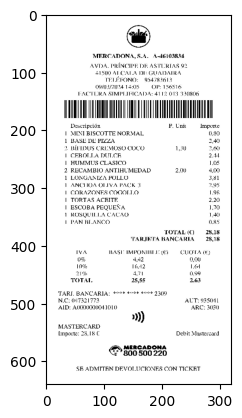

In [3]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.show()

In [4]:
import io
import numpy as np

image_io = io.BytesIO()
np.save(image_io, encoded_image, allow_pickle=True)
payload = image_io.getvalue()

In [106]:
import time

infer_start_time = time.time()

runtime_sm_client = boto3.client(service_name="sagemaker-runtime", region_name="us-east-1")
endpoint_name = "yolov8-pytorch-2024-08-21-20-32-14-863267"
    
response = runtime_sm_client.invoke_endpoint(
    EndpointName=endpoint_name,
    Body=payload,
    ContentType="application/x-npy"
    )
    
result = json.load(response["Body"])

infer_end_time = time.time()
print(f"Inference Time = {infer_end_time - infer_start_time:0.4f} seconds")

Inference Time = 0.9313 seconds


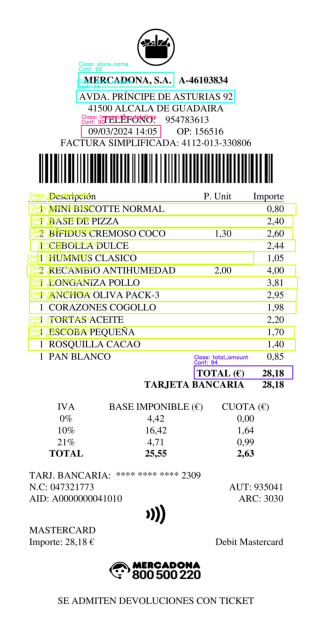

In [28]:
receipt_image_copy = receipt_image.copy()
classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}


if "boxes" in result:
    for idx, (x1, y1, x2, y2, conf, lbl) in enumerate(result["boxes"]):
        # If confidence lower than 0.5, do not draw the bounding box
        if conf < 0.5:
            continue

        # Map label int with its text value
        lbl_name = classes_mapper.get(lbl)
        
        # Choose a color for the bounding box
        if lbl_name == "item_description":
            color = (0, 255, 206)
        elif lbl_name == "store_address":
            color = (255, 255, 0)
        elif lbl_name == "store_name":
            color = (199, 252, 0)
        elif lbl_name == "total_amount":
            color = (254, 0, 86)
        else:
            color = (134, 34, 255) 

        # Draw Bounding Boxes
        x1, x2 = int(x_ratio*x1), int(x_ratio*x2)
        y1, y2 = int(y_ratio*y1), int(y_ratio*y2)

        cv2.rectangle(receipt_image_copy, (x1,y1), (x2,y2), color, 4)
        cv2.putText(receipt_image_copy, f"Class: {lbl_name}", (x1,y1-40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)
        cv2.putText(receipt_image_copy, f"Conf: {int(conf*100)}", (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

dpi = 200
figsize = (image_width / dpi, image_height / dpi)   

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(receipt_image_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

---

In [91]:
import base64
import boto3
import json
import io
import numpy as np


def lambda_handler(event, context):
    base64_image = event["receipt_image"]
    base64_decoded_image = base64.b64decode(base64_image)

    np_array = np.frombuffer(base64_decoded_image, np.uint8)
    image_io = io.BytesIO()
    np.save(image_io, np_array, allow_pickle=True)
    payload = image_io.getvalue()

    
    runtime_sm_client = boto3.client(service_name="sagemaker-runtime", region_name="us-east-1")
    endpoint_name = "yolov8-pytorch-2024-08-21-20-32-14-863267"
        
    response = runtime_sm_client.invoke_endpoint(
        EndpointName=endpoint_name,
        Body=payload,
        ContentType="application/x-npy"
        )
    
    result = json.load(response["Body"])
    
    return {
        "statusCode": 200,
        "body": json.dumps(result)
    }

In [29]:
lambda_client = boto3.client("lambda", region_name = "us-east-1")

In [92]:
response = lambda_client.invoke(
    FunctionName="sagemaker-yolov8-inference",
    InvocationType="RequestResponse",
    Payload=json.dumps({"receipt_image": base64_image})
)

In [93]:
response_payload = json.load(response["Payload"])
response_payload

{'statusCode': 200,
 'body': '{"boxes": [[201.87973022460938, 369.71392822265625, 309.88201904296875, 383.37603759765625, 0.9464800357818604, 3.0], [78.19972229003906, 119.84982299804688, 165.1860809326172, 132.57510375976562, 0.9000394344329834, 4.0], [21.403900146484375, 303.0269470214844, 313.4872741699219, 315.4276428222656, 0.8903907537460327, 0.0], [23.245208740234375, 213.75146484375, 310.3612365722656, 225.5284423828125, 0.8762848973274231, 0.0], [21.54705810546875, 289.91107177734375, 314.6630859375, 302.58209228515625, 0.8758518099784851, 0.0], [20.50946044921875, 341.8853759765625, 312.78961181640625, 353.96612548828125, 0.8699727654457092, 0.0], [22.505584716796875, 238.63217163085938, 312.5524597167969, 250.79861450195312, 0.8658813238143921, 0.0], [21.60516357421875, 226.41351318359375, 309.9822998046875, 238.67324829101562, 0.8645511269569397, 0.0], [21.70147705078125, 276.7589111328125, 314.9828796386719, 289.64617919921875, 0.8198562264442444, 0.0], [72.89817810058594,

In [94]:
bboxes_payload = json.loads(response_payload["body"])
bboxes_payload

{'boxes': [[201.87973022460938,
   369.71392822265625,
   309.88201904296875,
   383.37603759765625,
   0.9464800357818604,
   3.0],
  [78.19972229003906,
   119.84982299804688,
   165.1860809326172,
   132.57510375976562,
   0.9000394344329834,
   4.0],
  [21.403900146484375,
   303.0269470214844,
   313.4872741699219,
   315.4276428222656,
   0.8903907537460327,
   0.0],
  [23.245208740234375,
   213.75146484375,
   310.3612365722656,
   225.5284423828125,
   0.8762848973274231,
   0.0],
  [21.54705810546875,
   289.91107177734375,
   314.6630859375,
   302.58209228515625,
   0.8758518099784851,
   0.0],
  [20.50946044921875,
   341.8853759765625,
   312.78961181640625,
   353.96612548828125,
   0.8699727654457092,
   0.0],
  [22.505584716796875,
   238.63217163085938,
   312.5524597167969,
   250.79861450195312,
   0.8658813238143921,
   0.0],
  [21.60516357421875,
   226.41351318359375,
   309.9822998046875,
   238.67324829101562,
   0.8645511269569397,
   0.0],
  [21.7014770507812